# Annotation of cell masks with drawing in napari

In [1]:
import os
import numpy as np
import pandas as pd
import anndata as ad
import matplotlib.pyplot as plt
import spatialdata as sd
import napari
from napari_spatialdata import Interactive
import seaborn as sns
from shapely.geometry import Point, Polygon
from spatialdata.models import Labels2DModel, ShapesModel
import geopandas as gpd
import matplotlib.patches as mpatches

In [2]:
base_dir = "/Volumes/labs/scp/Imaging/ZeissAxio/Charu/2026" #define your path, if using server
#base_dir = '/Users/charu.sharma/Library/CloudStorage/OneDrive-KarolinskaInstitutet/Desktop/image_raw' #if using local
#base_dir = '/proj/scproteomics/users/x_chsha/raw_image_data' # if using tetralith
#base_dir = 'L:/Users/Charu/image_raw' #on imaging computer

In [3]:
img_folder = '260917_Ting_20x'
sdata_dir = os.path.join(base_dir, img_folder, 'cellpose_output')

In [6]:
adata_all = ad.read_h5ad(os.path.join(sdata_dir, 'cell_table_filter_trans_pu1.h5ad'))

### Add a spatial data layer with filtered cell layer 

In [8]:
# get unique slide names from filtered adata
slide_names = adata_all.obs['slide_name'].unique()

for slide_name in slide_names:
    zarr_path = os.path.join(sdata_dir, f'{slide_name}.zarr')
    if not os.path.exists(zarr_path):
        print(f"{slide_name}: zarr not found, skipping")
        continue

    print(f"Processing {slide_name}...")

    # get cell ids that passed filtering for this slide
    kept_ids = adata_all[adata_all.obs['slide_name'] == slide_name].obs['cell_id'].values
    print(f"  Kept cells: {len(kept_ids)}")

    # load sdata
    sdata = sd.read_zarr(zarr_path)

    # find masks layer
    masks_key = [k for k in sdata.labels.keys() if k.endswith('_masks')][0]
    mask = sdata.labels[masks_key].compute().values

    # create filtered mask — set removed cells to 0
    filtered_mask = np.where(np.isin(mask, kept_ids), mask, 0).astype(np.int32)
    print(f"  Original cells: {len(np.unique(mask)) - 1}")  # -1 for background
    print(f"  Filtered cells: {len(np.unique(filtered_mask)) - 1}")

    # save as new label layer
    filtered_key = masks_key.replace('_masks', '_masks_filtered')
    sdata.labels[filtered_key] = Labels2DModel.parse(filtered_mask)
    sdata.write_element(filtered_key)
    print(f"  Saved layer: {filtered_key}")

Processing 20260917_CML_1...
  Kept cells: 57044


no parent found for <ome_zarr.reader.Label object at 0x35ff9ff50>: None


  Original cells: 59516
  Filtered cells: 57044
  Saved layer: 20260917_CML_1.czi_masks_filtered
Processing 20260917_CML_2_rescan...
  Kept cells: 60095


no parent found for <ome_zarr.reader.Label object at 0x3660ce9d0>: None


  Original cells: 62702
  Filtered cells: 60095
  Saved layer: 20260917_CML_2_rescan.czi_masks_filtered
Processing 20260917_CML_metal_scene0...
  Kept cells: 50627


no parent found for <ome_zarr.reader.Label object at 0x35ffa9290>: None


  Original cells: 52477
  Filtered cells: 50627
  Saved layer: 20260917_CML_metal_masks_filtered
Processing 20260917_CML_metal_scene1...
  Kept cells: 50980


no parent found for <ome_zarr.reader.Label object at 0x389137690>: None


  Original cells: 53062
  Filtered cells: 50980
  Saved layer: 20260917_CML_metal_masks_filtered


### Annotate cells by drawing shapes in napari

In [9]:
sdata_dict = {}
zarr_files = sorted([f for f in os.listdir(sdata_dir) if f.endswith('.zarr')])

for zarr_file in zarr_files:
    slide_name = zarr_file.replace('.zarr', '')
    sdata_dict[slide_name] = sd.read_zarr(os.path.join(sdata_dir, zarr_file))
    print(f"Loaded: {slide_name}")

no parent found for <ome_zarr.reader.Label object at 0x3568ae6d0>: None
no parent found for <ome_zarr.reader.Label object at 0x3681dd110>: None


Loaded: 20260917_CML_1


no parent found for <ome_zarr.reader.Label object at 0x36817a510>: None
no parent found for <ome_zarr.reader.Label object at 0x36d6d8d50>: None


Loaded: 20260917_CML_2_rescan


no parent found for <ome_zarr.reader.Label object at 0x35ffc1010>: None
no parent found for <ome_zarr.reader.Label object at 0x36d6c4610>: None


Loaded: 20260917_CML_metal_scene0


no parent found for <ome_zarr.reader.Label object at 0x3569335d0>: None
no parent found for <ome_zarr.reader.Label object at 0x35692fdd0>: None


Loaded: 20260917_CML_metal_scene1


In [ ]:

slide_name = '20260917_CML_metal_scene1'


Interactive(sdata_dict[slide_name])

2026-09-23 11:14:51.985 | WARNING  | napari_spatialdata._viewer:__init__:56 - Due to Shift-L being used as shortcut in napari, it is being deprecated and might not link a new layer to an existing SpatialData object in the viewer. Please use ⌘-L on MacOS or else Ctrl-L.


/opt/anaconda3/envs/dvp_io/lib/python3.11/functools.py:909: ImplicitModificationWarning: Transforming to str index.
  return dispatch(args[0].__class__)(*args, **kw)
2026-09-23 11:15:08.445 | DEBUG    | napari_spatialdata._view:_on_layer_update:569 - Updating layer.
2026-09-23 11:15:08.447 | DEBUG    | napari_spatialdata._view:_on_layer_update:569 - Updating layer.
/opt/anaconda3/envs/dvp_io/lib/python3.11/site-packages/napari/_vispy/layers/scalar_field.py:219: UserWarning: data shape (29632, 33330) exceeds GL_MAX_TEXTURE_SIZE 16384 in at least one axis and will be downsampled. Rendering is currently in 2D mode.
  warnings.warn(
2026-09-23 11:17:23.867 | DEBUG    | napari_spatialdata._view:_on_layer_update:569 - Updating layer.
2026-09-23 11:17:23.868 | DEBUG    | napari_spatialdata._view:_on_layer_update:569 - Updating layer.
2026-09-23 11:17:23.879 | DEBUG    | napari_spatialdata._view:_on_layer_update:569 - Updating layer.
2026-09-23 11:17:23.882 | DEBUG    | napari_spatialdata._vie

INFO: Layer(s) inherited info from image
INFO: Layer saved


In [ ]:
## for CML_1 and CML_metalscene0
shape_labels = {
    0: 'P2_3_T',
    1: 'R1_3_C',
    2: 'R1_3_L',
    3: 'OS1_2_L',
    4:'OS1_2_', 
    5: 'P2_3_C',
    6:'OS1_2_C',
    7: 'P2_3_L', 
    8: 'R1_3_T'
}

In [28]:
v = napari.current_viewer()
shapes_layer = v.layers['Sample_category']  # change to your layer name

# assign label to each drawn shape
shape_labels = {
    0: 'R1_2_T',
    1: 'P3_1_C',
    2: 'P3_1_L',
    3: 'CFA_L2_L',
    4:'CFA_L2_T', 
    5: 'R1_2_C',
    6:'CFA_L2_C',
    7: 'R1_2_L', 
    8: 'P3_1_T'
}

# convert napari shapes to geodataframe and save to sdata
shapes_data = []
labels_data = []

for i, shape in enumerate(shapes_layer.data):
    if shape.shape[1] == 3:
        coords = [(pt[2], pt[1]) for pt in shape]  # (x,y) from (z,y,x)
    else:
        coords = [(pt[1], pt[0]) for pt in shape]  # (x,y) from (y,x)
    shapes_data.append(Polygon(coords))
    labels_data.append(shape_labels.get(i, 'unassigned'))

gdf = gpd.GeoDataFrame({
    'sample_category': labels_data,
    'geometry': shapes_data
})

# save to sdata_dict in memory
sdata_dict[slide_name].shapes['Sample_category'] = ShapesModel.parse(gdf)
sdata_dict[slide_name].write_element('Sample_category')
print(f"Saved {len(gdf)} annotation shapes for {slide_name}")
print(gdf[['sample_category']])

Saved 9 annotation shapes for 20260917_CML_metal_scene1
  sample_category
0          R1_2_T
1          P3_1_C
2          P3_1_L
3        CFA_L2_L
4        CFA_L2_T
5          R1_2_C
6        CFA_L2_C
7          R1_2_L
8          P3_1_T


### Add a new column annotation in the cell table from the shapes drawn in the napari window

In [34]:
from shapely.geometry import Point
import geopandas as gpd

adata_all.obs['Sample_category'] = 'unassigned'

for slide_name, sdata in sdata_dict.items():

    if 'Sample_category' not in sdata.shapes:
        print(f"{slide_name}: no annotations, skipping")
        continue

    print(f"Annotating {slide_name}...")

    gdf = sdata.shapes['Sample_category']
    slide_mask = adata_all.obs['slide_name'] == slide_name
    slide_cells = adata_all[slide_mask].obs

    # convert cells to geodataframe of points
    cells_gdf = gpd.GeoDataFrame(
        slide_cells,
        geometry=[Point(x, y) for x, y in zip(slide_cells['centroid_x'], slide_cells['centroid_y'])]
    )

    # spatial join — finds which polygon each point falls in
    joined = gpd.sjoin(cells_gdf, gdf[['sample_category', 'geometry']], 
                       how='left', predicate='within')

    # update adata — fill unmatched with 'unassigned'
    joined['sample_category'] = joined['sample_category'].fillna('unassigned')
    adata_all.obs.loc[joined.index, 'Sample_category'] = joined['sample_category'].values

    n_annotated = (joined['sample_category'] != 'unassigned').sum()
    print(f"  Annotated {n_annotated} / {slide_mask.sum()} cells")

print("\nAnnotation summary:")
print(adata_all.obs['Sample_category'].value_counts())

Annotating 20260917_CML_1...
  Annotated 56985 / 57044 cells
Annotating 20260917_CML_2_rescan...
  Annotated 59817 / 60095 cells
Annotating 20260917_CML_metal_scene0...
  Annotated 50115 / 50627 cells
Annotating 20260917_CML_metal_scene1...
  Annotated 50916 / 50980 cells

Annotation summary:
Sample_category
R1_2_T        29670
P3_1_C        22451
P2_3_L        20138
P2_3_C        19295
P2_3_T        14622
P3_1_T        13290
R1_3_C        11620
R1_2_L        11354
R1_3_L        10362
CFA_L2_L       9946
CFA_L2_C       9425
OS1_2_C        9248
P3_1_L         8658
R1_3_T         8627
OS1_2_L        8107
OS1_2_         5081
CFA_L2_T       4667
R1_2_C         1272
unassigned      913
Name: count, dtype: int64


In [46]:
# save
adata_all.write_h5ad(os.path.join(sdata_dir, 'cell_table_sample_annt.h5ad'))
print("Saved")

Saved


In [20]:
adata_all = ad.read_h5ad(os.path.join(sdata_dir, 'cell_table_sample_annt.h5ad'))

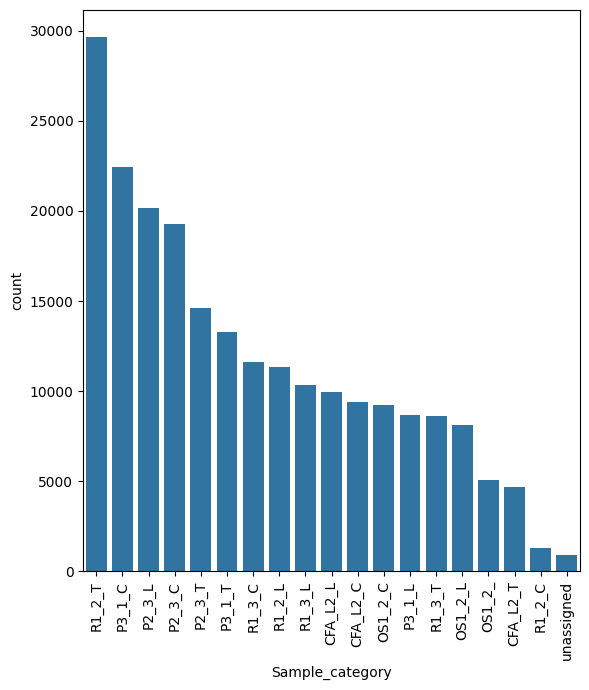

In [43]:
counts = adata_all.obs['Sample_category'].value_counts().reset_index()
counts.columns = ['Sample_category', 'count']

fig, ax = plt.subplots(figsize=(6, 7))
sns.barplot(data=counts, x='Sample_category', y ='count', ax=ax)
ax.tick_params(axis='x', rotation=90)
plt.tight_layout()
plt.show()

/var/folders/z6/cfm52_9963n20qy01gl86h_m0000gp/T/ipykernel_85318/3221777249.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  counts = adata_all.obs.groupby(['Sample_category', 'Pu1_class']).size().reset_index(name='count')
/var/folders/z6/cfm52_9963n20qy01gl86h_m0000gp/T/ipykernel_85318/3221777249.py:19: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(slides, rotation=90)


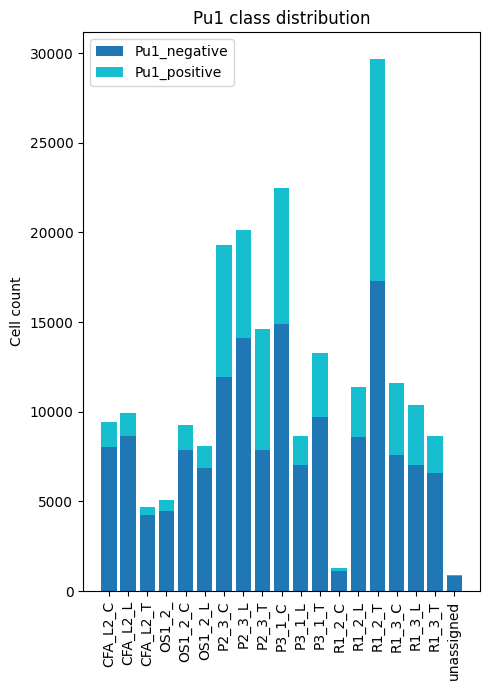

In [45]:
import matplotlib.patches as mpatches

counts = adata_all.obs.groupby(['Sample_category', 'Pu1_class']).size().reset_index(name='count')
classes = counts['Pu1_class'].unique()
slides = counts['Sample_category'].unique()
colors = plt.cm.tab10(np.linspace(0, 1, len(classes)))

fig, ax = plt.subplots(figsize=(5, 7))
bottom = np.zeros(len(slides))

for cls, color in zip(classes, colors):
    values = [counts[(counts['Sample_category'] == s) & (counts['Pu1_class'] == cls)]['count'].sum() for s in slides]
    ax.bar(slides, values, bottom=bottom, color=color, label=cls)
    bottom += np.array(values)

ax.set_xlabel('')
ax.set_ylabel('Cell count')
ax.set_title('Pu1 class distribution')
ax.set_xticklabels(slides, rotation=90)
ax.legend()
plt.tight_layout()
plt.show()

### Manual lesion annotation -
20260917 - Ting 20x --- DVP trial round 1

In [4]:
sdata_dict_new = {}
zarr_files = sorted([f for f in os.listdir(sdata_dir) if f.endswith('.zarr')])

for zarr_file in zarr_files:
    slide_name = zarr_file.replace('.zarr', '')
    sdata_dict_new[slide_name] = sd.read_zarr(os.path.join(sdata_dir, zarr_file))
    print(f"Loaded: {slide_name}")

no parent found for <ome_zarr.reader.Label object at 0x1699d0c90>: None
no parent found for <ome_zarr.reader.Label object at 0x169e77e10>: None


Loaded: 20260917_CML_1


no parent found for <ome_zarr.reader.Label object at 0x169e74090>: None
no parent found for <ome_zarr.reader.Label object at 0x317bfa9d0>: None


Loaded: 20260917_CML_2_rescan


no parent found for <ome_zarr.reader.Label object at 0x169ea7890>: None
no parent found for <ome_zarr.reader.Label object at 0x169eaf890>: None


Loaded: 20260917_CML_metal_scene0


no parent found for <ome_zarr.reader.Label object at 0x366cab190>: None
no parent found for <ome_zarr.reader.Label object at 0x366cacf50>: None


Loaded: 20260917_CML_metal_scene1


In [32]:
slide_name = '20260917_CML_2_rescan'

In [14]:
Interactive(sdata_dict_new[slide_name])

2026-09-25 14:17:36.862 | WARNING  | napari_spatialdata._viewer:__init__:56 - Due to Shift-L being used as shortcut in napari, it is being deprecated and might not link a new layer to an existing SpatialData object in the viewer. Please use ⌘-L on MacOS or else Ctrl-L.


In [42]:
# repeat for each of your 3 new layers
layer_name = 'CORE'
shapes_layer = v.layers[layer_name]

# extract coordinates
shapes_data = []
for shape in shapes_layer.data:
    if shape.shape[1] == 3:
        coords = [(pt[2], pt[1]) for pt in shape]
    else:
        coords = [(pt[1], pt[0]) for pt in shape]
    shapes_data.append(Polygon(coords))

gdf = gpd.GeoDataFrame(geometry=shapes_data)

# save to sdata in memory AND to disk
sdata_dict_new[slide_name].shapes[layer_name] = ShapesModel.parse(gdf)
sdata_dict_new[slide_name].write_element(layer_name, overwrite=True)
print(f"Saved {len(gdf)} shapes for {layer_name}")

Saved 25 shapes for CORE


### Updating the anndata object based on annotations where index is not clear
This will visualise the sdata image with the shapes layer and the index, to manually create a dict, which can help update the anndata object

In [ ]:
rescan =sd.read_zarr(os.path.join(sdata_dir, '20260917_CML_2_rescan.zarr'))

no parent found for <ome_zarr.reader.Label object at 0x84708ce90>: None
no parent found for <ome_zarr.reader.Label object at 0x39179dcd0>: None


2026-09-25 16:28:06.935 | DEBUG    | napari_spatialdata._view:_on_layer_update:569 - Updating layer.
2026-09-25 16:28:11.850 | DEBUG    | napari_spatialdata._view:_on_layer_update:569 - Updating layer.


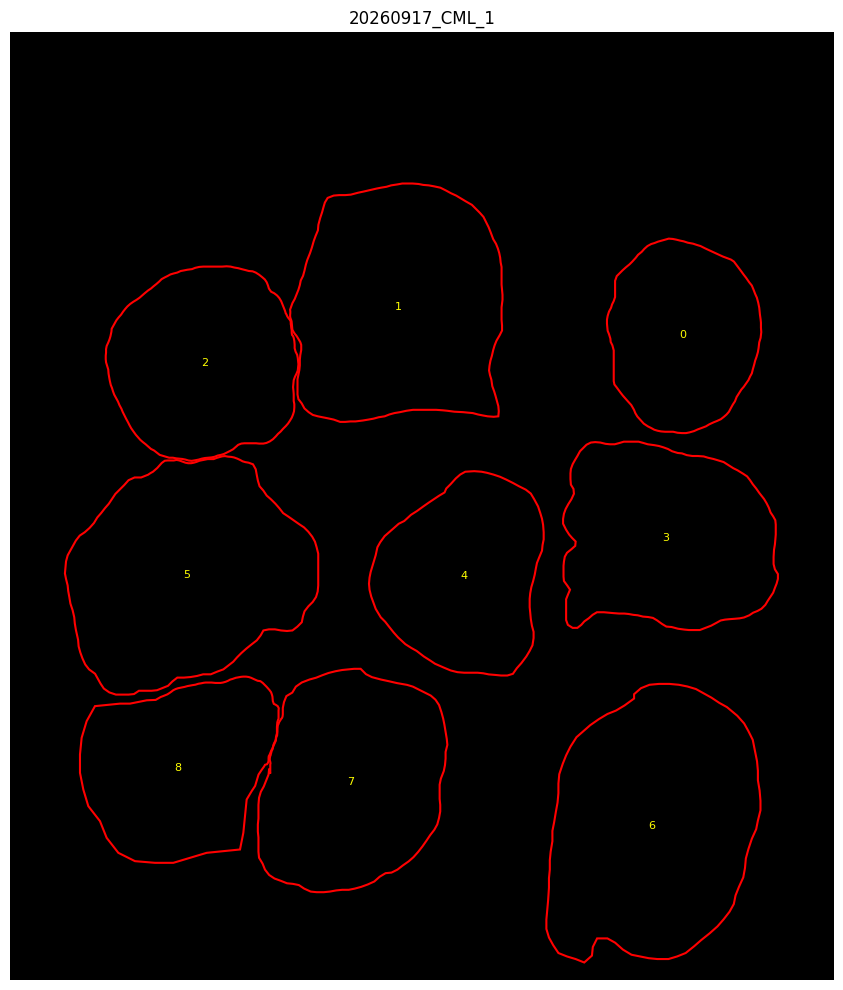

In [27]:
fig, ax = plt.subplots(figsize=(14, 10))

img_key = list(sdata_dict_new['20260917_CML_1'].images.keys())[0]
img = sdata_dict_new['20260917_CML_1'][img_key]

ds = 8
thumb = img.isel(c=0).coarsen(y=ds, x=ds, boundary='trim').mean().compute().values
scale = 1 / ds

p1, p99 = np.percentile(thumb, (1, 99))
ax.imshow(np.clip(thumb, p1, p99), cmap='gray')

gdf = sdata_dict_new['20260917_CML_1'].shapes['Sample_category']
for i, (_, row) in enumerate(gdf.iterrows()):
    coords = np.array(row.geometry.exterior.coords) * scale
    ax.add_patch(mpatches.Polygon(coords, closed=True, fill=False, edgecolor='red', linewidth=1.5))
    cx, cy = row.geometry.centroid.x * scale, row.geometry.centroid.y * scale
    ax.text(cx, cy, str(i), fontsize=8, color='yellow', ha='center', va='center',
            bbox=dict(boxstyle='round,pad=0.2', facecolor='black', alpha=0.5, edgecolor='none'))

ax.set_title('20260917_CML_1')
ax.axis('off')
plt.tight_layout()
plt.show()

In [ ]:
na_gm_dict_scene0={'GM':[0,5,6,7,8,9,17,18],
                   'WM':[1,2,3,4,10,11,12,13,14,15,16,19,20,21,22]}

na_gm_dict_scene1={'GM':[0,5,6,12,16,20],
                    'WM':[1,2,3,4,7,8,9,10,11,13,14,15,17,18,19,21,22]}

na_gm_dict_1={'GM':[0,6,7,11,13,15],
                    'WM':[1,2,3,4,5,8,9,10,12,14,18,19,16,17]}

na_gm_dict_2_rescan={'GM':[0,3,8,13,14,18],
                    'WM':[1,2,4,5,6,7,9,10,11,12,19,20,15,16,17]}



### Labels all cells insie the core, vbo and gm shape as such

In [ ]:
# ── PARAMETERS — change these per slide ───────────────────────────────────────
slide_name = '20260917_CML_metal_scene1'

na_gm_dict={'GM':[0,5,6,12,16,20],
                    'WM':[1,2,3,4,7,8,9,10,11,13,14,15,17,18,19,21,22]}

uniform_layers = {'VBO': 'vbo', 'CORE': 'core'}

# ── GET CELLS FOR THIS SLIDE ──────────────────────────────────────────────────
sdata = sdata_dict_new[slide_name]
slide_mask = adata_all.obs['slide_name'] == slide_name
slide_cells = adata_all[slide_mask].obs

cells_gdf = gpd.GeoDataFrame(
    slide_cells,
    geometry=[Point(x, y) for x, y in zip(slide_cells['centroid_x'], slide_cells['centroid_y'])]
)

# ── 1. NA_GW_WM — use dict mapping label to list of shape indices ─────────────
if 'NA_GW_WM' in sdata.shapes:
    gdf = sdata.shapes['NA_GW_WM'].copy()
    # reverse dict: index -> label
    index_to_label = {idx: label for label, indices in na_gm_dict.items() for idx in indices}
    gdf['label'] = [index_to_label.get(i, 'unassigned') for i in range(len(gdf))]

    joined = gpd.sjoin(cells_gdf, gdf[['label', 'geometry']], how='left', predicate='within')
    matched = joined['label'].notna() & (joined['label'] != 'unassigned')
    adata_all.obs.loc[joined[matched].index, 'manual_annotation'] = joined[matched]['label'].values
    print(f"NA_GW_WM: {matched.sum()} cells annotated")

# ── 2. VBO AND CORE — all shapes get same label ───────────────────────────────
for layer_name, label in uniform_layers.items():
    if layer_name not in sdata.shapes:
        continue
    gdf = sdata.shapes[layer_name].copy()
    gdf['label'] = label

    joined = gpd.sjoin(cells_gdf, gdf[['label', 'geometry']], how='left', predicate='within')
    matched = joined['label'].notna()
    adata_all.obs.loc[joined[matched].index, 'manual_annotation'] = joined[matched]['label'].values
    print(f"{layer_name}: {matched.sum()} cells annotated")

print("\nAnnotation summary for this slide:")
print(adata_all[slide_mask].obs['manual_annotation'].value_counts())

NA_GW_WM: 8766 cells annotated
VBO: 121 cells annotated
CORE: 2873 cells annotated

Annotation summary for this slide:
manual_annotation
GM      6234
core    2873
WM      2532
vbo      121
Name: count, dtype: int64


/var/folders/z6/cfm52_9963n20qy01gl86h_m0000gp/T/ipykernel_53625/838083866.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  counts = pu1_cat.obs.groupby(['Sample_category', 'manual_annotation']).size().reset_index(name='count')
/var/folders/z6/cfm52_9963n20qy01gl86h_m0000gp/T/ipykernel_53625/838083866.py:17: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(slides, rotation=90)


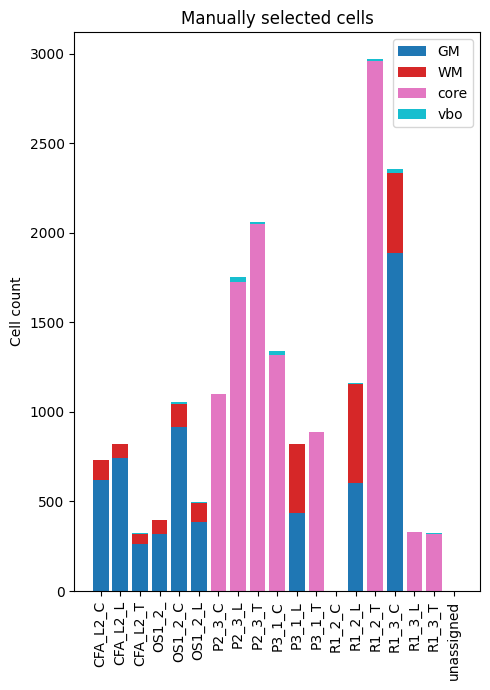

In [63]:
counts = pu1_cat.obs.groupby(['Sample_category', 'manual_annotation']).size().reset_index(name='count')
classes = counts['manual_annotation'].unique()
slides = counts['Sample_category'].unique()
colors = plt.cm.tab10(np.linspace(0, 1, len(classes)))

fig, ax = plt.subplots(figsize=(5, 7))
bottom = np.zeros(len(slides))

for cls, color in zip(classes, colors):
    values = [counts[(counts['Sample_category'] == s) & (counts['manual_annotation'] == cls)]['count'].sum() for s in slides]
    ax.bar(slides, values, bottom=bottom, color=color, label=cls)
    bottom += np.array(values)

ax.set_xlabel('')
ax.set_ylabel('Cell count')
ax.set_title('Manually selected cells')
ax.set_xticklabels(slides, rotation=90)
ax.legend()
plt.tight_layout()
plt.show()

In [54]:
adata_all.write_h5ad(os.path.join(sdata_dir, 'cell_table_full_annotated_v1.h5ad'))

In [56]:
new_adata = ad.read_h5ad(os.path.join(sdata_dir, 'cell_table_full_annotated_v1.h5ad'))

In [61]:
pu1_cat = new_adata[new_adata.obs['Pu1_class']=='Pu1_positive']

In [62]:
pu1_cat

View of AnnData object with n_obs × n_vars = 64023 × 4
    obs: 'cell_id', 'slide_name', 'centroid_x', 'centroid_y', 'area', 'eccentricity', 'perimeter', 'solidity', 'major_axis_length', 'minor_axis_length', 'convex_area', 'Pu1_class', 'Sample_category', 'manual_annotation'
    obsm: 'spatial'
    layers: 'clipped', 'normalised_transformed'

### Cell selection for each well

In [15]:
cell_table = ad.read_h5ad(os.path.join(sdata_dir, 'cell_table_full_annotated_v1.h5ad'))

In [16]:
pixel_size_um = 0.325  # um per pixel
cell_table.obs['area_um2'] = cell_table.obs['area'] * (pixel_size_um ** 2)

In [14]:
print(cell_table.obs['Sample_category'].unique())

['unassigned', 'R1_3_C', 'P2_3_T', 'R1_3_L', 'OS1_2_L', ..., 'CFA_L2_T', 'CFA_L2_L', 'P3_1_T', 'R1_2_L', 'CFA_L2_C']
Length: 19
Categories (19, object): ['CFA_L2_C', 'CFA_L2_L', 'CFA_L2_T', 'OS1_2_', ..., 'R1_3_C', 'R1_3_L', 'R1_3_T', 'unassigned']


In [17]:
cell_table.obs

,cell_id,slide_name,centroid_x,centroid_y,area,eccentricity,perimeter,solidity,major_axis_length,minor_axis_length,convex_area,Pu1_class,Sample_category,manual_annotation,area_um2
20260917_CML_1_1,1,20260917_CML_1,18239.062827,1917.869110,191.0,0.493860,50.627417,0.955000,16.955790,14.743764,200.0,Pu1_positive,unassigned,NaN,20.174375
20260917_CML_1_2,2,20260917_CML_1,18251.564644,1926.810026,379.0,0.771000,74.526912,0.947500,27.653992,17.611020,400.0,Pu1_positive,unassigned,NaN,40.031875
20260917_CML_1_3,3,20260917_CML_1,21121.492683,4334.627642,615.0,0.721823,92.911688,0.971564,33.753140,23.359800,633.0,Pu1_negative,unassigned,NaN,64.959375
20260917_CML_1_4,4,20260917_CML_1,11388.126280,4625.819113,293.0,0.829421,64.870058,0.976667,25.892047,14.463938,300.0,Pu1_negative,R1_3_C,NaN,30.948125
20260917_CML_1_5,5,20260917_CML_1,11479.900000,4627.051724,290.0,0.897860,71.355339,0.923567,29.494847,12.986047,314.0,Pu1_negative,R1_3_C,NaN,30.631250
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
20260917_CML_metal_scene1_53058,53058,20260917_CML_metal_scene1,23069.899563,29315.241630,687.0,0.763631,99.154329,0.974468,36.831349,23.780249,705.0,Pu1_negative,CFA_L2_C,NaN,72.564375
20260917_CML_metal_scene1_53059,53059,20260917_CML_metal_scene1,22927.345714,29311.694286,350.0,0.814700,72.526912,0.945946,27.786926,16.113143,370.0,Pu1_negative,CFA_L2_C,NaN,36.968750
20260917_CML_metal_scene1_53060,53060,20260917_CML_metal_scene1,22945.898551,29310.891304,276.0,0.499437,63.698485,0.920000,20.378100,17.654565,300.0,Pu1_negative,CFA_L2_C,NaN,29.152500
20260917_CML_metal_scene1_53061,53061,20260917_CML_metal_scene1,23146.348039,29312.335784,408.0,0.875630,79.840620,0.964539,32.935490,15.907256,423.0,Pu1_negative,CFA_L2_C,NaN,43.095000


In [ ]:
#cell_table = cell_table[cell_table.obs['slide_name']!= '20260917_CML_1']

In [ ]:
from shapely.ops import unary_union

# ── PARAMETERS ────────────────────────────────────────────────────────────────
target_area_um2 = 3000
pixel_size_um = 0.325
ring_distances_um = [0, 100, 200, 400]
ring_distances_px = [d / pixel_size_um for d in ring_distances_um]
edge_exclusion_um = 100
edge_exclusion_px = edge_exclusion_um / pixel_size_um

# ── STEP 1 — FILTER PU1 POSITIVE ──────────────────────────────────────────────
pu1_cells = cell_table[cell_table.obs['Pu1_class'] == 'Pu1_positive'].obs.copy()
print(f"Pu1 positive cells: {len(pu1_cells)}")

cell_table.obs['cells_selected'] = np.nan
group_id = 1

def select_cells(cells, target_area_um2, group_label):
    global group_id
    if len(cells) == 0:
        print(f"    ⚠ {group_label}: no cells available")
        return
    median_area = cells['area_um2'].median()
    std_area = cells['area_um2'].std()
    cells = cells[(cells['area_um2'] >= median_area - std_area) &
                  (cells['area_um2'] <= median_area + std_area)]
    if len(cells) == 0:
        print(f"    ⚠ {group_label}: no cells after size filter")
        return
    cells = cells.sort_values(['slide_name', 'centroid_x', 'centroid_y'])
    cells['cumsum'] = cells['area_um2'].cumsum()
    selected = cells[cells['cumsum'] <= target_area_um2]
    total = selected['area_um2'].sum()
    if total < target_area_um2:
        print(f"    ⚠ {group_label}: only {total:.0f} µm² available (target {target_area_um2})")
    if len(selected) > 0:
        cell_table.obs.loc[selected.index, 'cells_selected'] = group_id
        print(f"    ✓ {group_label}: {len(selected)} cells, {total:.0f} µm² → group {group_id}")
        group_id += 1

def filter_directional(cells, core_gdf, tissue_centroid):
    """Keep only cells on the inward side of their nearest core (toward tissue centroid)."""
    keep = []
    tissue_pt = np.array([tissue_centroid.x, tissue_centroid.y])
    
    for idx, row in cells.iterrows():
        cell_pt = np.array([row['centroid_x'], row['centroid_y']])
        
        # find nearest core and use its centroid as reference
        cell_geom = Point(row['centroid_x'], row['centroid_y'])
        nearest_core = min(core_gdf.geometry, key=lambda g: g.centroid.distance(cell_geom))
        core_pt = np.array(nearest_core.centroid.coords[0])
        
        # inward vector: from nearest core centroid toward tissue centroid
        inward_vec = tissue_pt - core_pt
        
        # cell vector: from nearest core centroid toward cell
        cell_vec = cell_pt - core_pt
        
        if np.dot(cell_vec, inward_vec) > 0:
            keep.append(idx)
    
    return cells.loc[keep]

# ── STEP 2 — COMPUTE DISTANCES PER SLIDE ─────────────────────────────────────
all_ring_cells = []
all_core_cells = []
all_gm_wm_cells = []

for slide_name in pu1_cells['slide_name'].unique():
    slide_cells = pu1_cells[pu1_cells['slide_name'] == slide_name]
    sdata = sdata_dict_new[slide_name]

    vbo_union = None
    if 'VBO' in sdata.shapes:
        vbo_union = unary_union([geom.buffer(0) for geom in sdata.shapes['VBO'].geometry])

    core_gdf = sdata.shapes['CORE'] if 'CORE' in sdata.shapes else None
    sample_cat_gdf = sdata.shapes['Sample_category'] if 'Sample_category' in sdata.shapes else None

    print(f"\nComputing spatial for {slide_name}...")

    for sample_cat in slide_cells['Sample_category'].unique():
        if sample_cat == 'unassigned':
            continue

        cat_cells = slide_cells[slide_cells['Sample_category'] == sample_cat]

        # get tissue polygon for this sample_category
        tissue_polygon = None
        tissue_centroid = None
        eroded_polygon = None
        if sample_cat_gdf is not None:
            match = sample_cat_gdf[sample_cat_gdf['sample_category'] == sample_cat]
            if len(match) > 0:
                tissue_polygon = unary_union([g.buffer(0) for g in match.geometry])
                tissue_centroid = tissue_polygon.centroid
                eroded_polygon = tissue_polygon.buffer(-edge_exclusion_px)

        for annotation in cat_cells['manual_annotation'].unique():
            if annotation in ['unassigned', 'vbo']:
                continue

            ann_cells = cat_cells[cat_cells['manual_annotation'] == annotation].copy()

            # ── GM / WM — no edge exclusion ───────────────────────────────────
            if annotation in ['GM', 'WM']:
                all_gm_wm_cells.append(ann_cells)

            # ── CORE ──────────────────────────────────────────────────────────
            elif annotation == 'core':
                if core_gdf is None:
                    continue

                cells_gdf = gpd.GeoDataFrame(
                    ann_cells,
                    geometry=[Point(x, y) for x, y in
                              zip(ann_cells['centroid_x'], ann_cells['centroid_y'])]
                )

                # core cells inside shape — no edge exclusion
                joined = gpd.sjoin(cells_gdf, core_gdf[['geometry']],
                                   how='inner', predicate='within')
                core_cells = ann_cells.loc[joined.index.unique()].copy()
                all_core_cells.append(core_cells)

                # distance rings
                core_union = unary_union([geom.buffer(0) for geom in core_gdf.geometry])

                non_core_cells = cat_cells[
                    ~cat_cells['manual_annotation'].isin(['core', 'vbo'])
                ].copy()

                # exclude VBO spatially
                if vbo_union is not None:
                    points = [Point(x, y) for x, y in
                              zip(non_core_cells['centroid_x'], non_core_cells['centroid_y'])]
                    not_in_vbo = [not vbo_union.contains(p) for p in points]
                    non_core_cells = non_core_cells[not_in_vbo]

                # exclude cells within edge_exclusion_px of tissue boundary
                if eroded_polygon is not None and not eroded_polygon.is_empty:
                    points = [Point(x, y) for x, y in
                              zip(non_core_cells['centroid_x'], non_core_cells['centroid_y'])]
                    inside_eroded = [eroded_polygon.contains(p) for p in points]
                    non_core_cells = non_core_cells[inside_eroded]
                    print(f"  {sample_cat}: {sum(inside_eroded)}/{len(inside_eroded)} cells after edge exclusion")

                # directional filter — only cells toward tissue centroid
                if tissue_centroid is not None and len(non_core_cells) > 0:
                    n_before = len(non_core_cells)
                    non_core_cells = filter_directional(non_core_cells, core_gdf, tissue_centroid)
                    print(f"  {sample_cat}: {len(non_core_cells)}/{n_before} cells after directional filter")

                # compute distance to core boundary
                points = [Point(x, y) for x, y in
                          zip(non_core_cells['centroid_x'], non_core_cells['centroid_y'])]
                non_core_cells['dist_px'] = [core_union.boundary.distance(p) for p in points]
                all_ring_cells.append(non_core_cells)

# ── STEP 3 — POOL ACROSS SLIDES AND SELECT CELLS ─────────────────────────────
gm_wm_df = pd.concat(all_gm_wm_cells) if all_gm_wm_cells else pd.DataFrame()
core_df = pd.concat(all_core_cells) if all_core_cells else pd.DataFrame()
ring_df = pd.concat(all_ring_cells) if all_ring_cells else pd.DataFrame()

print("\n── Selecting cells across all slides ──")

for sample_cat in pu1_cells['Sample_category'].unique():
    if sample_cat == 'unassigned':
        continue

    print(f"\n{sample_cat}")

    # GM / WM
    for annotation in ['GM', 'WM']:
        if not gm_wm_df.empty:
            cells = gm_wm_df[
                (gm_wm_df['Sample_category'] == sample_cat) &
                (gm_wm_df['manual_annotation'] == annotation)
            ]
            if len(cells) > 0:
                select_cells(cells, target_area_um2, f"{annotation} | {sample_cat}")

    # core inside
    if not core_df.empty:
        cells = core_df[core_df['Sample_category'] == sample_cat]
        if len(cells) > 0:
            select_cells(cells, target_area_um2, f"core_inside | {sample_cat}")

    # distance rings
    if not ring_df.empty:
        ring_cat = ring_df[ring_df['Sample_category'] == sample_cat]
        for i in range(len(ring_distances_px) - 1):
            d_min = ring_distances_px[i]
            d_max = ring_distances_px[i + 1]
            d_min_um = ring_distances_um[i]
            d_max_um = ring_distances_um[i + 1]
            ring_cells = ring_cat[
                (ring_cat['dist_px'] >= d_min) &
                (ring_cat['dist_px'] < d_max)
            ]
            if len(ring_cells) > 0:
                select_cells(ring_cells, target_area_um2,
                             f"core_ring_{d_min_um}-{d_max_um}um | {sample_cat}")

print(f"\nTotal groups: {group_id - 1}")
print(cell_table.obs['cells_selected'].value_counts().sort_index())

Pu1 positive cells: 64023

Computing spatial for 20260917_CML_1...
  P2_3_T: 1664/2297 cells after edge exclusion
  P2_3_T: 1458/1664 cells after directional filter
  R1_3_L: 1108/1537 cells after edge exclusion
  R1_3_L: 1015/1108 cells after directional filter
  P2_3_C: 2747/3571 cells after edge exclusion
  P2_3_C: 2410/2747 cells after directional filter
  P2_3_L: 1721/2038 cells after edge exclusion
  P2_3_L: 1545/1721 cells after directional filter
  R1_3_T: 691/888 cells after edge exclusion
  R1_3_T: 652/691 cells after directional filter

Computing spatial for 20260917_CML_2_rescan...
  R1_2_T: 2518/2852 cells after edge exclusion
  R1_2_T: 1988/2518 cells after directional filter
  P3_1_C: 2238/2395 cells after edge exclusion
  P3_1_C: 1606/2238 cells after directional filter
  P3_1_T: 1074/1259 cells after edge exclusion
  P3_1_T: 970/1074 cells after directional filter

Computing spatial for 20260917_CML_metal_scene0...
  P2_3_T: 1787/2379 cells after edge exclusion
  P2_3_

In [19]:
for slide_name in cell_table.obs['slide_name'].unique():
    sdata = sdata_dict_new[slide_name]

    masks_key = [k for k in sdata.labels.keys() if k.endswith('_masks')][0]
    mask = sdata.labels[masks_key].compute().values

    slide_obs = cell_table.obs[cell_table.obs['slide_name'] == slide_name]
    selected = slide_obs.dropna(subset=['cells_selected'])

    # use mask max for lookup size to cover all possible cell ids
    max_cell_id = int(mask.max()) + 1
    lookup = np.zeros(max_cell_id, dtype=np.int32)
    for _, row in selected.iterrows():
        lookup[int(row['cell_id'])] = int(row['cells_selected'])

    selected_mask = lookup[mask]

    sdata.labels['cells_selected'] = Labels2DModel.parse(selected_mask)
    print(f"{slide_name}: {np.unique(selected_mask[selected_mask > 0]).shape[0]} groups added to memory")

20260917_CML_1: 28 groups added to memory
20260917_CML_2_rescan: 22 groups added to memory
20260917_CML_metal_scene0: 9 groups added to memory
20260917_CML_metal_scene1: 6 groups added to memory


In [ ]:
Interactive(sdata_dict_new['20260917_CML_1'])

2026-09-28 15:57:06.224 | WARNING  | napari_spatialdata._viewer:__init__:56 - Due to Shift-L being used as shortcut in napari, it is being deprecated and might not link a new layer to an existing SpatialData object in the viewer. Please use ⌘-L on MacOS or else Ctrl-L.


/opt/anaconda3/envs/dvp_io/lib/python3.11/functools.py:909: ImplicitModificationWarning: Transforming to str index.
  return dispatch(args[0].__class__)(*args, **kw)
2026-09-28 15:57:26.136 | DEBUG    | napari_spatialdata._view:_on_layer_update:569 - Updating layer.
2026-09-28 15:57:26.137 | DEBUG    | napari_spatialdata._view:_on_layer_update:569 - Updating layer.


INFO: Please wait for the current operation to finish.


/opt/anaconda3/envs/dvp_io/lib/python3.11/site-packages/napari/_vispy/layers/scalar_field.py:219: UserWarning: data shape (27781, 24128) exceeds GL_MAX_TEXTURE_SIZE 16384 in at least one axis and will be downsampled. Rendering is currently in 2D mode.
  warnings.warn(
2026-09-28 16:00:43.410 | DEBUG    | napari_spatialdata._view:_on_layer_update:569 - Updating layer.
2026-09-28 16:00:43.412 | DEBUG    | napari_spatialdata._view:_on_layer_update:569 - Updating layer.
2026-09-28 16:00:43.874 | DEBUG    | napari_spatialdata._view:_on_layer_update:569 - Updating layer.
2026-09-28 16:00:43.877 | DEBUG    | napari_spatialdata._view:_on_layer_update:569 - Updating layer.
2026-09-28 16:00:58.416 | DEBUG    | napari_spatialdata._view:_on_layer_update:569 - Updating layer.
2026-09-28 16:00:58.432 | DEBUG    | napari_spatialdata._view:_on_layer_update:569 - Updating layer.
2026-09-28 16:00:58.435 | DEBUG    | napari_spatialdata._view:_on_layer_update:569 - Updating layer.
2026-09-28 16:00:59.593 

In [23]:
cell_table.write_h5ad(os.path.join(sdata_dir, 'cell_table_full_annotated_v2.h5ad'))